In [260]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [261]:
df = pd.read_csv('covid.csv')

df.sample(5)

,age,gender,fever,cough,city,has_covid
84540,64,Male,102.0,Mild,Bangalore,Yes
9849,20,Female,NaN,Strong,Mumbai,Yes
2383,8,Female,101.0,Mild,Kolkata,No
26638,12,Female,104.0,Mild,Bangalore,No
16955,64,Female,98.0,Mild,Bangalore,Yes


In [262]:
df.shape

(100000, 6)

In [263]:
df.isnull().sum()

age             0
gender          0
fever        9999
cough           0
city            0
has_covid       0
dtype: int64

In [264]:
df.describe()

,age,fever
count,100000.000000,90001.000000
mean,44.111580,100.842624
std,24.728932,2.046984
min,5.000000,98.000000
25%,20.000000,99.000000
50%,44.000000,101.000000
75%,66.000000,103.000000
max,84.000000,104.000000


In [265]:
df['fever'].isnull().mean()

np.float64(0.09999)

<Axes: ylabel='Density'>

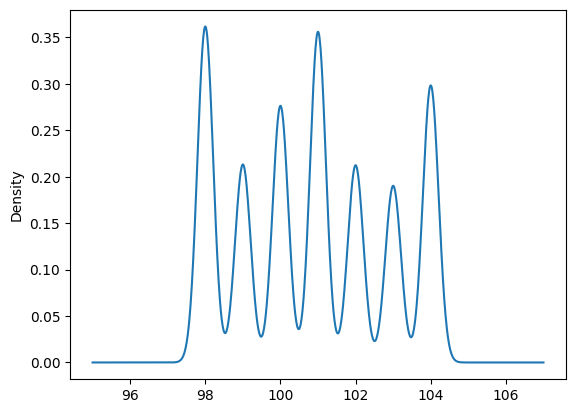

In [266]:
plt.Figure(figsize=(10,8))
df['fever'].plot(kind='kde')

In [267]:
mean_fever = df['fever'].mean()
median_fever = df['fever'].median()

df['fever_median'] = df['fever'].fillna(median_fever)
df['fever_mean'] = df['fever'].fillna(mean_fever)


df.sample(6)


,age,gender,fever,cough,city,has_covid,fever_median,fever_mean
3036,34,Female,NaN,Strong,Mumbai,Yes,101.0,100.842624
23460,34,Female,104.0,Strong,Delhi,No,104.0,104.000000
98448,16,Female,103.0,Mild,Bangalore,Yes,103.0,103.000000
9605,44,Male,104.0,Mild,Mumbai,No,104.0,104.000000
2065,25,Male,104.0,Mild,Bangalore,Yes,104.0,104.000000
59256,12,Female,104.0,Mild,Bangalore,No,104.0,104.000000


In [268]:
print('Original Fever variable variance: ', df['fever'].var())
print('Fever Variance after median imputation: ', df['fever_median'].var())
print('Fever Variance after mean imputation: ', df['fever_mean'].var())


Original Fever variable variance:  4.190143621367169
Fever Variance after median imputation:  3.7733958443584443
Fever Variance after mean imputation:  3.7711669709001616


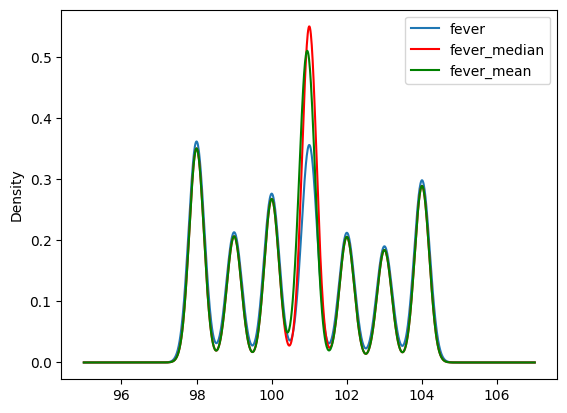

In [269]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
df['fever'].plot(kind='kde', ax=ax)

# variable imputed with the median
df['fever_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
df['fever_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

### we see that there is not much differece between Mean and Median so we can use any of them Imputation technique

##### We  used  the mean value herr to impute

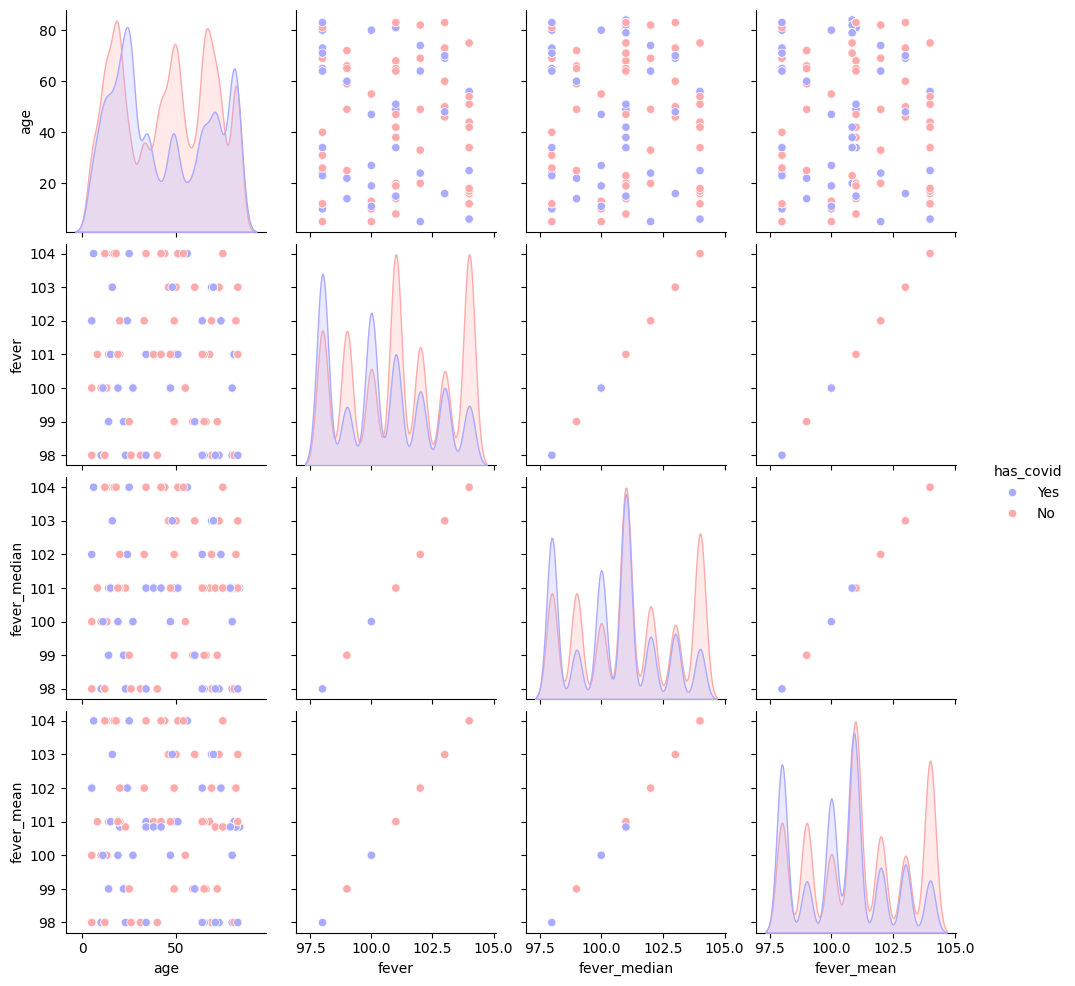

In [270]:
sns.pairplot(df,hue='has_covid',palette='bwr')

### Outliers Treatment

In [271]:
df.head(2)

,age,gender,fever,cough,city,has_covid,fever_median,fever_mean
0,11,Female,100.0,Strong,Kolkata,Yes,100.0,100.0
1,82,Female,102.0,Strong,Kolkata,No,102.0,102.0


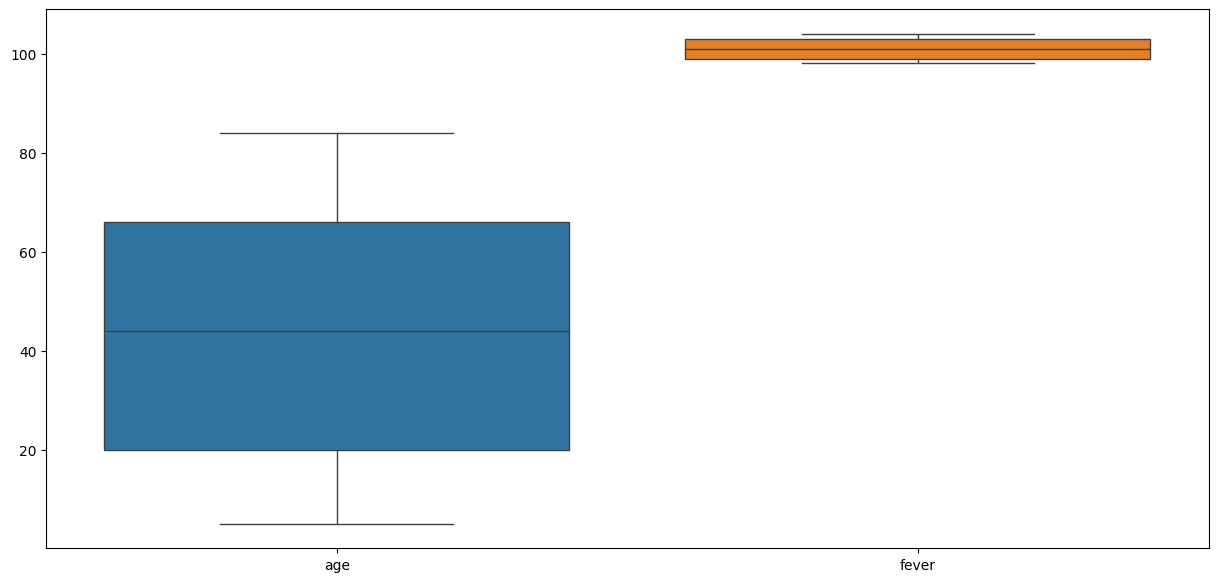

In [272]:
plt.figure(figsize=(15,7))
sns.boxplot(data = df[['age','fever']])
plt.show()

## there is no outliers in the given data so we can proceed further

In [273]:
x = df[['age', 'gender', 'cough', 'city', 'fever']]
y = df[['has_covid']]

In [274]:
X_train, X_test, y_train, y_test =  train_test_split(x,y,test_size=0.1,random_state=42)

### We will encode the label into numerical values(0,1)

In [289]:
le = LabelEncoder()

In [300]:

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
print(y_train.shape,
y_test.shape)

(90000,) (10000,)


In [301]:
from sklearn.compose import ColumnTransformer

In [302]:
transformer = ColumnTransformer(transformers=[
    ('tnf1',SimpleImputer(),['fever']),
    ('tnf2',OrdinalEncoder(categories=[['Mild','Strong']]),['cough']),
    ('tnf3',OneHotEncoder(drop='first'),['gender','city'])
],remainder='passthrough')

In [303]:
tr1 = LogisticRegression(max_iter=500)

In [304]:
pipe = Pipeline([
    ('transformer', transformer),('tr1',tr1)
])

In [305]:
pipe.fit(X_train,y_train)

,steps,"[('transformer', ...), ('tr1', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tnf1', ...), ('tnf2', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [306]:
y_pred=pipe.predict(X_test)
y_pred


array([1, 0, 0, ..., 1, 0, 0], shape=(10000,))

In [307]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [310]:
accuracy_score(y_test,y_pred)


0.611

In [311]:

scores = cross_val_score(pipe, x, y, cv=20, scoring='accuracy')

print("Cross-validation accuracy scores:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/uti

Cross-validation accuracy scores: [0.5888 0.6172 0.6062 0.599  0.613  0.6138 0.6128 0.6122 0.6134 0.6062
 0.618  0.6016 0.6206 0.6072 0.6148 0.6156 0.6128 0.6204 0.618  0.6188]
Mean accuracy: 0.6115200000000001
Standard deviation: 0.007807790980808853
